In [1]:
# ============================================================
# PART 1: Setup imports, device, and helper functions
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

# Device configuration (GPU, MPS, or CPU based on availability)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using device: CUDA (GPU)")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using device: CPU")

# TensorBoard (for logging)
from torch.utils.tensorboard import SummaryWriter

Using device: MPS (Apple Silicon GPU)


In [2]:
# ============================================================
# PART 2: Load and preprocess the dataset using DataLoader
# ============================================================

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torchvision.transforms.functional as Ff  # Correct import for image processing (as Ff)
import random


# ============================================================
# Custom Compose to apply multiple transformations to both image and mask
# ============================================================

class CustomCompose:
    def __init__(self, transforms):
        self.transforms = transforms
    
    def __call__(self, image, mask):
        for t in self.transforms:
            image, mask = t(image, mask)
        return image, mask


# ============================================================
# Random Crop and Resize for both image and mask
# ============================================================

class RandomCropAndResize:
    def __init__(self, target_size=(128, 128)):
        self.target_size = target_size
    
    def __call__(self, image, mask):
        # Randomly crop (using the correct function from torchvision.transforms.functional)
        i, j, h, w = transforms.RandomCrop.get_params(image, self.target_size)
        image = Ff.crop(image, i, j, h, w)  # Crop image using the correct method
        mask = Ff.crop(mask, i, j, h, w)    # Crop mask using the correct method
        
        # Resize to 128x128
        image = Ff.resize(image, self.target_size)
        mask = Ff.resize(mask, self.target_size)
        
        # Normalize image by dividing by 255 (0-1 range)
        image = Ff.to_tensor(image) / 255.0  # Convert to tensor and normalize
        mask = Ff.to_tensor(mask).long()  # Convert mask to tensor (for segmentation)

        return image, mask


# ============================================================
# Random Horizontal Flip (Augmentation) - for both image and mask
# ============================================================

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, image, mask):
        if random.random() < self.p:
            # Flip both image and mask horizontally
            image = Ff.hflip(image)
            mask = Ff.hflip(mask)
        return image, mask


# ============================================================
# Breast Cancer Segmentation Dataset
# ============================================================

class BreastCancerSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_files = sorted(os.listdir(image_dir))
        self.mask_files = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Load image and mask
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])
        
        image = Image.open(image_path).convert("RGB")  # Convert to RGB for consistency
        mask = Image.open(mask_path).convert("L")  # 'L' for grayscale mask
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)  # Both image and mask are passed
        
        return image, mask


# ============================================================
# Define transforms for training, validation, and testing
# ============================================================

train_transform = CustomCompose([
    RandomCropAndResize(target_size=(128, 128)),  # Crop and resize to 128x128
    RandomHorizontalFlip(p=0.5),  # Augmentation (horizontal flip)
])

val_transform = CustomCompose([
    RandomCropAndResize(target_size=(128, 128)),  # Crop and resize to 128x128
])

# Load datasets with the updated transformations
train_dataset = BreastCancerSegmentationDataset(
    image_dir="data/train/images", 
    mask_dir="data/train/masks", 
    transform=train_transform
)

val_dataset = BreastCancerSegmentationDataset(
    image_dir="data/val/images", 
    mask_dir="data/val/masks", 
    transform=val_transform
)

test_dataset = BreastCancerSegmentationDataset(
    image_dir="data/test/images", 
    mask_dir="data/test/masks", 
    transform=val_transform
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train dataset size: {len(train_loader.dataset)}")
print(f"Validation dataset size: {len(val_loader.dataset)}")

Train dataset size: 850
Validation dataset size: 40


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)

class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        self.double_conv = DoubleConv(in_channels, out_channels)
        self.down_sample = nn.MaxPool2d(2)

    def forward(self, x):
        skip_out = self.double_conv(x)
        down_out = self.down_sample(skip_out)
        return down_out, skip_out

class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, up_sample_mode='bilinear'):
        super(UpBlock, self).__init__()
        if up_sample_mode == 'conv_transpose':
            self.up_sample = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        elif up_sample_mode == 'bilinear':
            self.up_sample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            raise ValueError("Unsupported up_sample_mode. Use 'conv_transpose' or 'bilinear'")
        self.double_conv = DoubleConv(in_channels, out_channels)

    def forward(self, down_input, skip_input):
        x = self.up_sample(down_input)
        x = torch.cat([x, skip_input], dim=1)  # Concatenate skip connection
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, out_classes=1, up_sample_mode='bilinear'):
        super(UNet, self).__init__()
        # Downsampling path
        self.down_conv1 = DownBlock(3, 64)     # (3, 128, 128) -> (64, 64, 64)
        self.down_conv2 = DownBlock(64, 128)   # (64, 64, 64) -> (128, 32, 32)
        self.down_conv3 = DownBlock(128, 256)  # (128, 32, 32) -> (256, 16, 16)
        self.down_conv4 = DownBlock(256, 512)  # (256, 16, 16) -> (512, 8, 8)

        # Bottleneck
        self.middle = DoubleConv(512, 1024)    # (512, 8, 8) -> (1024, 8, 8)
        # Upsampling path
        self.up_conv4 = UpBlock(1024 + 512, 512, up_sample_mode)
        self.up_conv3 = UpBlock(512 + 256, 256, up_sample_mode)
        self.up_conv2 = UpBlock(256 + 128, 128, up_sample_mode)
        self.up_conv1 = UpBlock(128 + 64, 64, up_sample_mode)
        # Final output layer
        self.conv_last = nn.Conv2d(64, out_classes, kernel_size=1)  # Output 1 channel for segmentation

    def forward(self, x):
        # Encoder (down-sampling)
        x, skip1_out = self.down_conv1(x)
        x, skip2_out = self.down_conv2(x)
        x, skip3_out = self.down_conv3(x)
        x, skip4_out = self.down_conv4(x)
        # Bottleneck
        x = self.middle(x)
        # Decoder (up-sampling)
        x = self.up_conv4(x, skip4_out)
        x = self.up_conv3(x, skip3_out)
        x = self.up_conv2(x, skip2_out)
        x = self.up_conv1(x, skip1_out)

        # Final layer
        x = self.conv_last(x)
        return x

        

In [6]:
# ============================================================
# PART 4: Training Loop (with TensorBoard logging)
# ============================================================

import torch
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import torch.optim as optim
import torch.nn as nn
import os

# --- IoU (Intersection over Union) Calculation ---
def iou_score(preds, labels, threshold=0.5):
    preds = torch.sigmoid(preds) > threshold  # Apply sigmoid + threshold
    intersection = torch.sum(preds * labels)
    union = torch.sum(preds) + torch.sum(labels) - intersection
    iou = intersection.float() / (union.float() + 1e-6)
    return iou

# --- Dice Score Calculation ---
def dice_score(preds, labels, threshold=0.5):
    preds = torch.sigmoid(preds) > threshold  # Apply sigmoid + threshold
    intersection = torch.sum(preds * labels)
    dice = 2.0 * intersection.float() / (torch.sum(preds) + torch.sum(labels) + 1e-6)
    return dice

# Initialize model, optimizer, and loss function
model = UNet(out_classes=1).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss() 

# Create TensorBoard SummaryWriter
writer = SummaryWriter(log_dir="runs/unet_breast_cancer")

# Initialize lists to store history for Part 6 plotting
train_iou_values = []
train_dice_values = []
val_iou_values = []
val_dice_values = []

epochs = 10

print("Starting Training...")

for epoch in range(epochs):
    # --------------------------------------------------------
    # TRAINING PHASE
    # --------------------------------------------------------
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    train_dice = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        yb = yb.float()

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_iou += iou_score(preds, yb).item()
        train_dice += dice_score(preds, yb).item()

    # Average Training metrics
    train_loss /= len(train_loader)
    train_iou /= len(train_loader)
    train_dice /= len(train_loader)

    # --------------------------------------------------------
    # VALIDATION PHASE
    # --------------------------------------------------------
    model.eval()
    val_iou = 0.0
    val_dice = 0.0
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            yb = yb.float()
            
            preds = model(xb)
            
            val_iou += iou_score(preds, yb).item()
            val_dice += dice_score(preds, yb).item()

    # Average Validation metrics
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    # --------------------------------------------------------
    # LOGGING AND RECORDING
    # --------------------------------------------------------
    
    # 1. Save to Python lists for Part 6 line plots
    train_iou_values.append(train_iou)
    train_dice_values.append(train_dice)
    val_iou_values.append(val_iou)
    val_dice_values.append(val_dice)

    # 2. Log to TensorBoard
    writer.add_scalar("Loss/Train", train_loss, epoch)
    writer.add_scalar("IoU/Train", train_iou, epoch)
    writer.add_scalar("Dice/Train", train_dice, epoch)
    writer.add_scalar("IoU/Val", val_iou, epoch)
    writer.add_scalar("Dice/Val", val_dice, epoch)

    # 3. Print Progress
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  [Train] Loss: {train_loss:.4f} | IoU: {train_iou:.4f} | Dice: {train_dice:.4f}")
    print(f"  [Val]   IoU: {val_iou:.4f} | Dice: {val_dice:.4f}")
    print("-" * 30)

# Close TensorBoard writer
writer.close()
print("Training Complete.")

Starting Training...
Epoch 1/10
  [Train] Loss: 0.4719 | IoU: 0.2141 | Dice: 0.3388
  [Val]   IoU: 0.0000 | Dice: 0.0000
------------------------------
Epoch 2/10
  [Train] Loss: 0.3355 | IoU: 0.1949 | Dice: 0.3189
  [Val]   IoU: 0.2687 | Dice: 0.4067
------------------------------
Epoch 3/10
  [Train] Loss: 0.3027 | IoU: 0.2915 | Dice: 0.4442
  [Val]   IoU: 0.0000 | Dice: 0.0000
------------------------------
Epoch 4/10
  [Train] Loss: 0.2732 | IoU: 0.3532 | Dice: 0.5161
  [Val]   IoU: 0.0000 | Dice: 0.0000
------------------------------
Epoch 5/10
  [Train] Loss: 0.2635 | IoU: 0.3505 | Dice: 0.5135
  [Val]   IoU: 0.0000 | Dice: 0.0000
------------------------------
Epoch 6/10
  [Train] Loss: 0.2513 | IoU: 0.4105 | Dice: 0.5737
  [Val]   IoU: 0.1394 | Dice: 0.2389
------------------------------
Epoch 7/10
  [Train] Loss: 0.2398 | IoU: 0.4051 | Dice: 0.5711
  [Val]   IoU: 0.0000 | Dice: 0.0000
------------------------------
Epoch 8/10
  [Train] Loss: 0.2187 | IoU: 0.4592 | Dice: 0.6243

DEBUG: Logits range: [-5.1802, -3.5427]
DEBUG: Prob range: [0.0056, 0.0281]


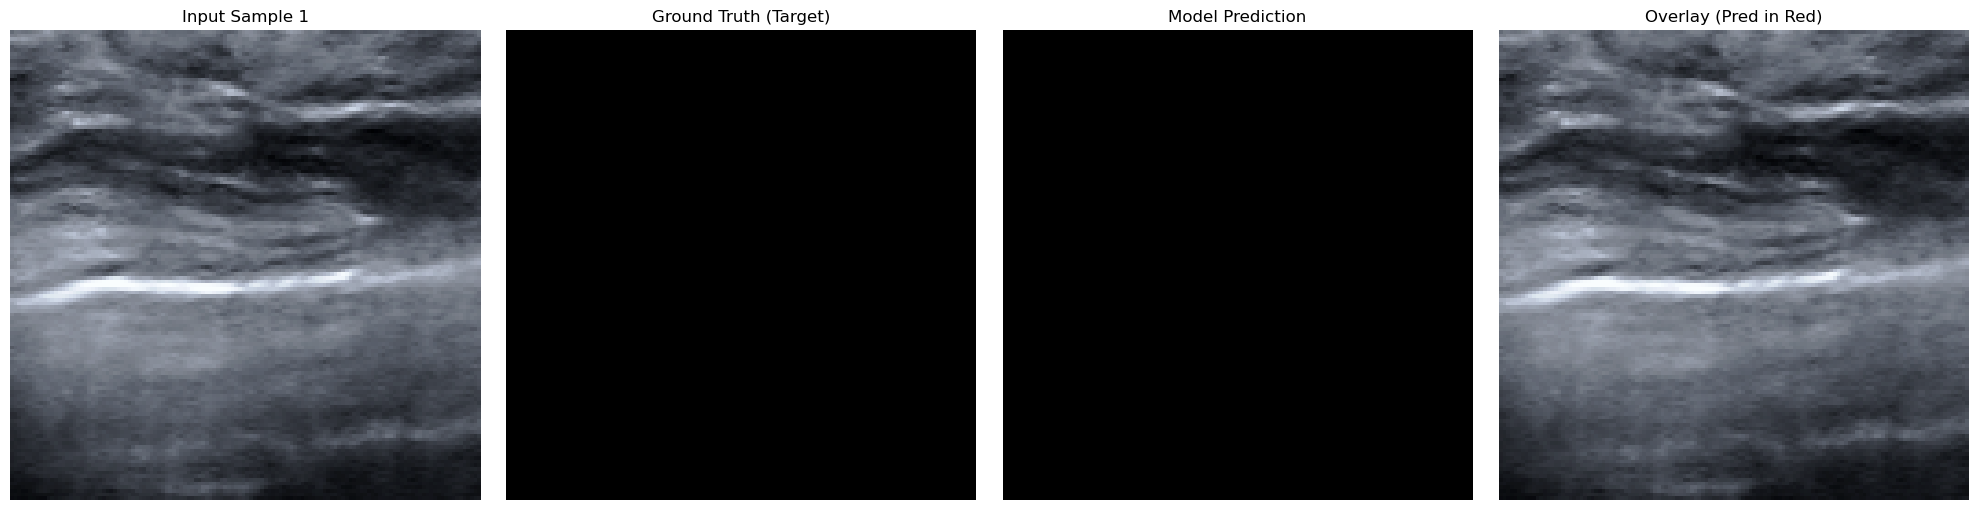

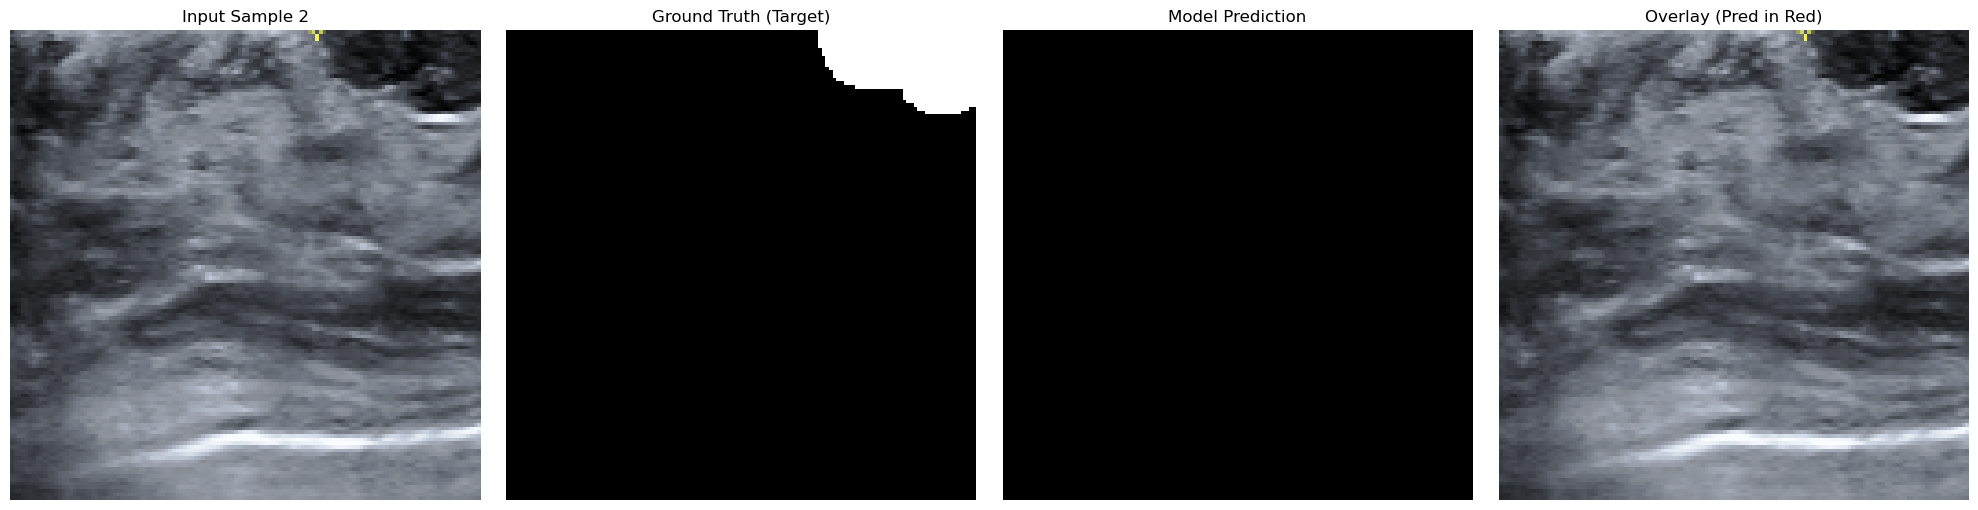

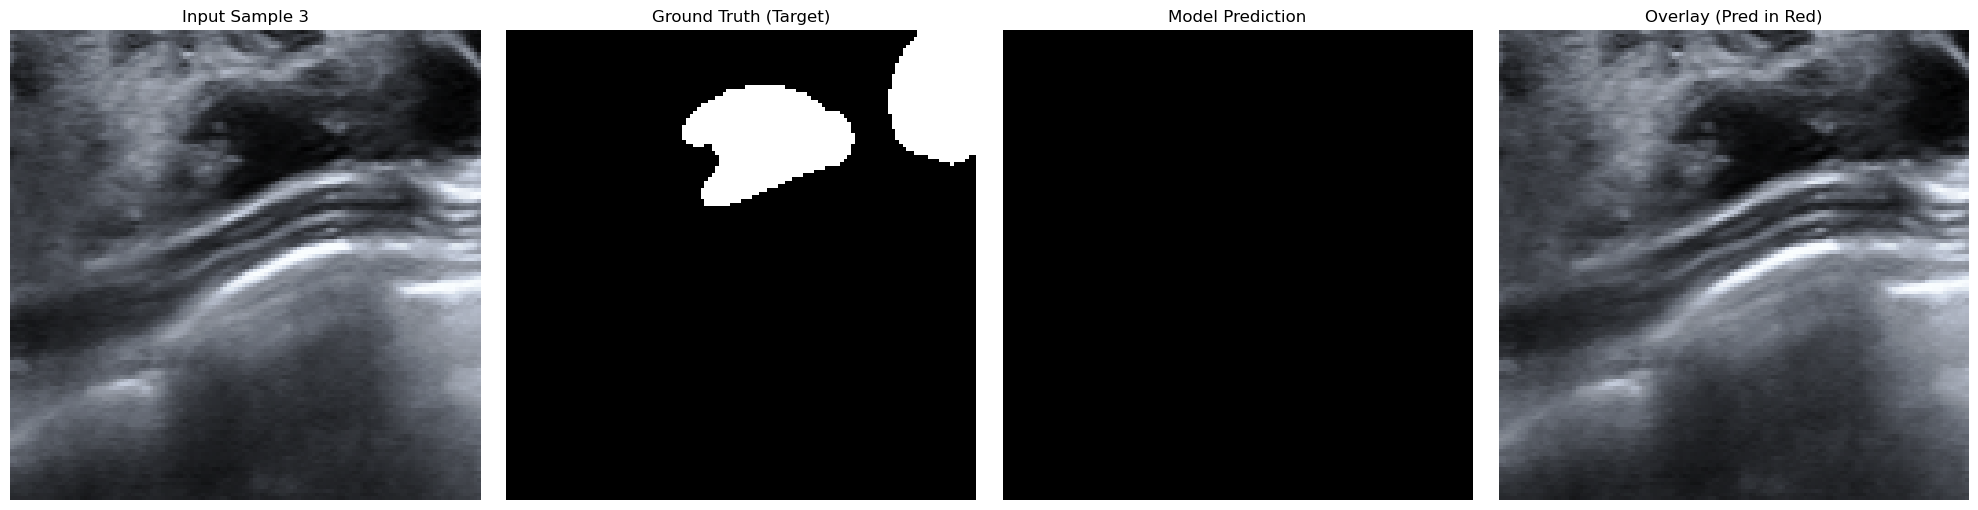

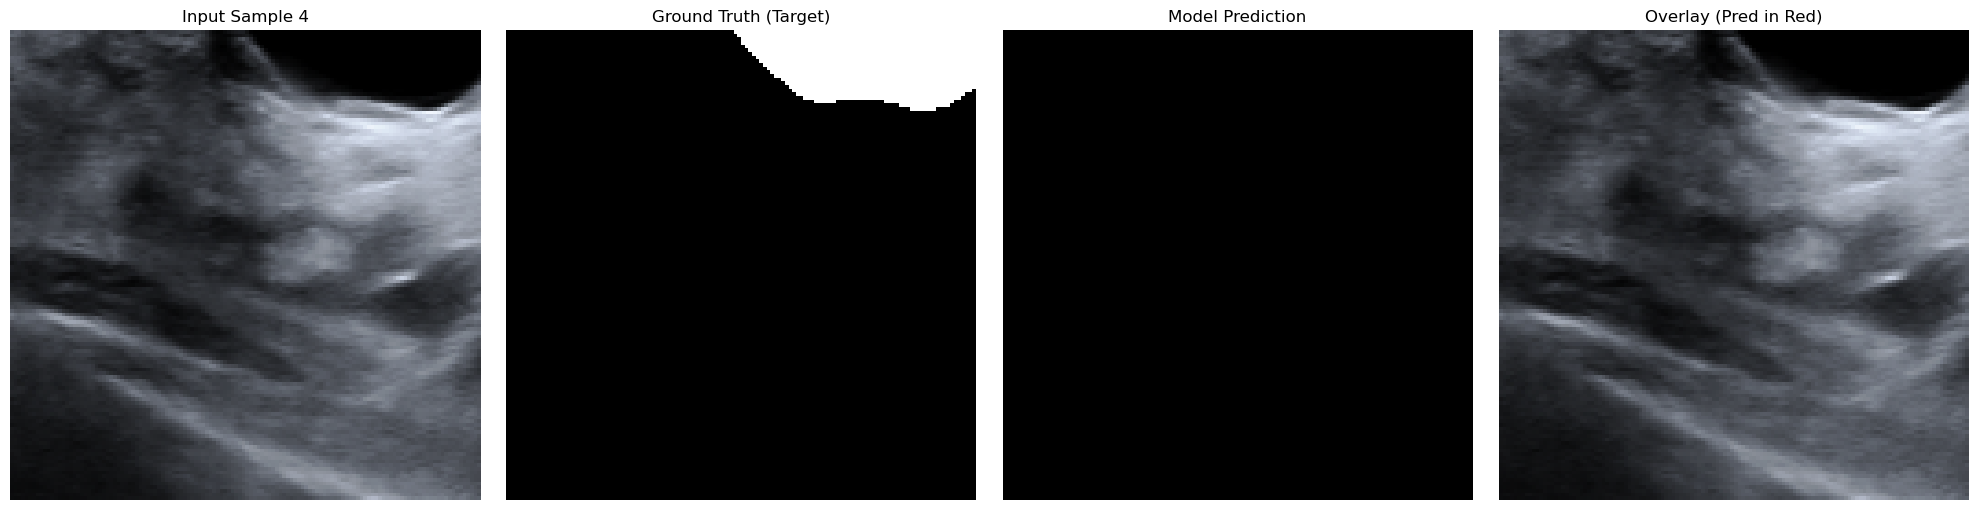

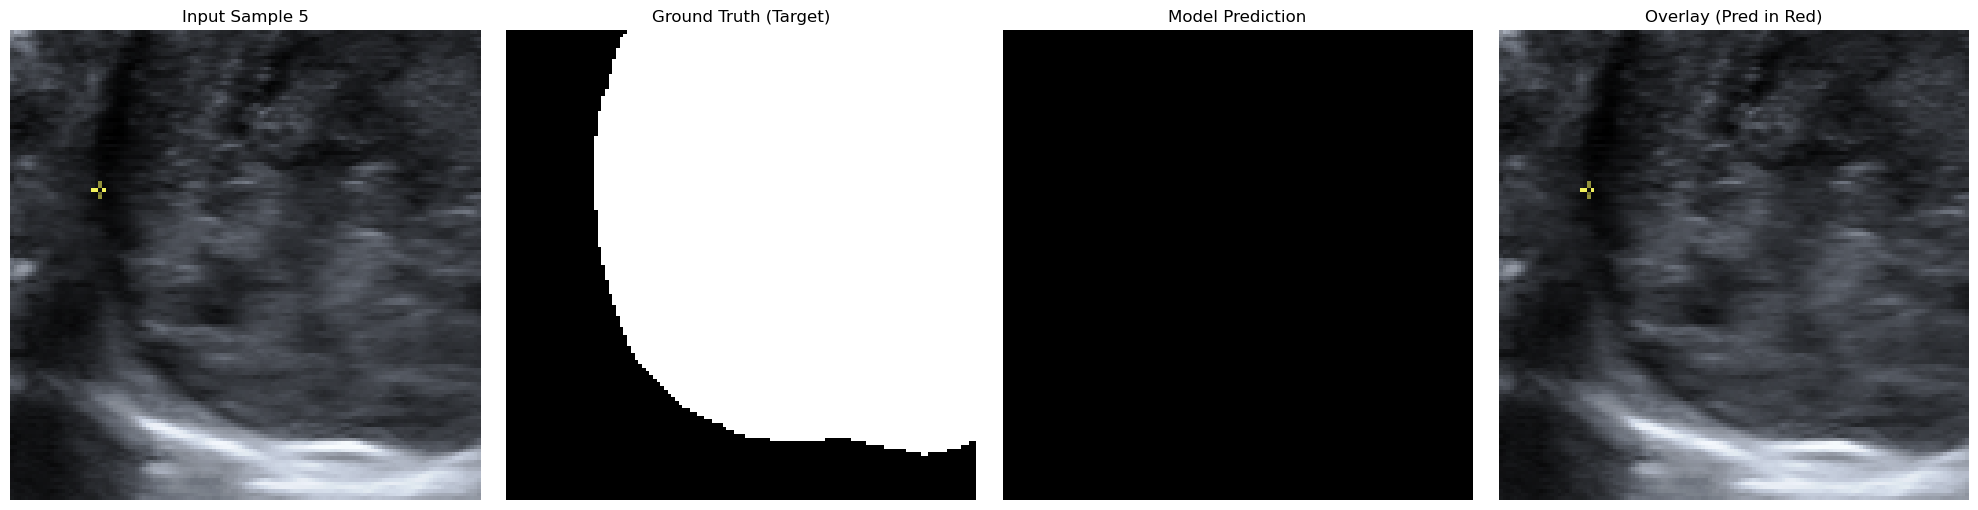

DEBUG: Logits range: [-5.2361, -2.6666]
DEBUG: Prob range: [0.0053, 0.0650]
DEBUG: Logits range: [-5.1745, -3.7320]
DEBUG: Prob range: [0.0056, 0.0234]
------------------------------
TEST METRICS:
Mean IoU:  0.0000
Mean Dice: 0.0000
------------------------------


In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ============================================================
# PART 5: Model Evaluation and Prediction Visualization
# ============================================================

def visualize_results(model, test_loader, device, num_samples=5):
    model.eval()
    test_iou = 0.0
    test_dice = 0.0
    samples_plotted = 0

    # Robust denormalization: Scales the specific image back to [0, 1] range
    def denormalize(img_tensor):
        low = img_tensor.min()
        high = img_tensor.max()
        # Prevent division by zero if image is blank
        return (img_tensor - low) / (high - low + 1e-8)

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            
            # Get model outputs
            logits = model(xb)
            
            print(f"DEBUG: Logits range: [{logits.min().item():.4f}, {logits.max().item():.4f}]")
            preds_prob = torch.sigmoid(logits)
            print(f"DEBUG: Prob range: [{preds_prob.min().item():.4f}, {preds_prob.max().item():.4f}]")
            # ----------------------------------
            # Apply Sigmoid to convert logits to probabilities (0.0 to 1.0)
            preds_prob = torch.sigmoid(logits)
            # preds_binary = (preds_prob > 0.01).float()
            preds_binary = (preds_prob > 0.5).float()

            # Calculate metrics for this batch
            # Note: Ensure your iou_score and dice_score functions handle tensors
            test_iou += iou_score(preds_binary, yb).item()
            test_dice += dice_score(preds_binary, yb).item()

            # Visualization Logic
            for i in range(xb.size(0)):
                if samples_plotted < num_samples:
                    # 1. Process Image
                    # Convert from (C, H, W) to (H, W, C)
                    img_np = xb[i].cpu().numpy().transpose(1, 2, 0)
                    img_view = denormalize(img_np) 

                    # 2. Process Masks
                    # Squeeze removes the channel dimension: (1, 128, 128) -> (128, 128)
                    gt_mask = yb[i].cpu().numpy().squeeze()
                    pred_mask = preds_binary[i].cpu().numpy().squeeze()

                    # 3. Create Prediction Overlay
                    # We create a copy of the image and tint predicted pixels RED
                    overlay = img_view.copy()
                    
                    # If it's a 3-channel RGB image
                    if overlay.ndim == 3 and overlay.shape[-1] == 3:
                        overlay[pred_mask == 1] = [1, 0, 0] 
                    else:
                        # For grayscale images, just use the mask
                        overlay = pred_mask 

                    # --- Plotting ---
                    plt.figure(figsize=(20, 5))
                    
                    plt.subplot(1, 4, 1)
                    plt.imshow(img_view)
                    plt.title(f"Input Sample {samples_plotted + 1}")
                    plt.axis('off')
                    
                    plt.subplot(1, 4, 2)
                    plt.imshow(gt_mask, cmap='gray')
                    plt.title("Ground Truth (Target)")
                    plt.axis('off')
                    
                    plt.subplot(1, 4, 3)
                    plt.imshow(pred_mask, cmap='gray')
                    plt.title("Model Prediction")
                    plt.axis('off')
                    
                    plt.subplot(1, 4, 4)
                    plt.imshow(overlay)
                    plt.title("Overlay (Pred in Red)")
                    plt.axis('off')
                    
                    plt.tight_layout()
                    plt.show()
                    
                    samples_plotted += 1
                else:
                    break

        # Calculate final average metrics
        avg_iou = test_iou / len(test_loader)
        avg_dice = test_dice / len(test_loader)
        print("-" * 30)
        print(f"TEST METRICS:")
        print(f"Mean IoU:  {avg_iou:.4f}")
        print(f"Mean Dice: {avg_dice:.4f}")
        print("-" * 30)

# Run the visualization
visualize_results(model, test_loader, device)

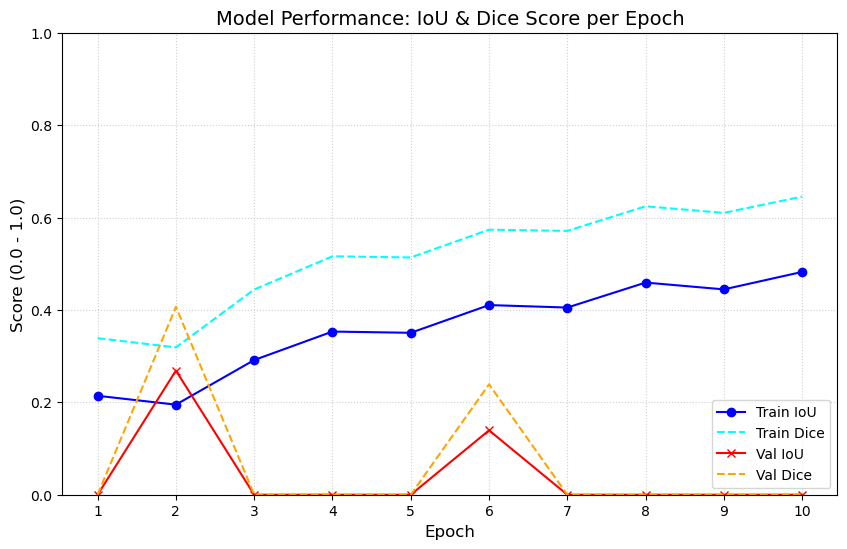

In [8]:
# ============================================================
# PART 6: Line Plot for IoU and Dice Score over Epochs
# ============================================================
import matplotlib.pyplot as plt

# Ensure we have data to plot
if len(train_iou_values) > 0:
    plt.figure(figsize=(10, 6))
    
    # Create x-axis values (Epoch 1, 2, ...)
    epoch_range = range(1, len(train_iou_values) + 1)

    # Plot Training Metrics
    plt.plot(epoch_range, train_iou_values, label="Train IoU", color='blue', marker='o')
    plt.plot(epoch_range, train_dice_values, label="Train Dice", color='cyan', linestyle='--')

    # Plot Validation Metrics
    plt.plot(epoch_range, val_iou_values, label="Val IoU", color='red', marker='x')
    plt.plot(epoch_range, val_dice_values, label="Val Dice", color='orange', linestyle='--')

    # Formatting the plot
    plt.title("Model Performance: IoU & Dice Score per Epoch", fontsize=14)
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
    plt.xticks(epoch_range) # Ensure only integer epoch numbers show
    plt.ylim(0, 1)          # Metrics are usually between 0 and 1
    plt.legend(loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()
else:
    print("Error: No data found. Please re-run Part 4 with the list appending code.")